# 04. Customer Retention and Churn Interventions

Retention analytics is often presented as a prediction problem:

> Which customers are most likely to churn?

That is useful, but it is not the decision problem. The decision problem is:

> Which customers should receive an intervention because the intervention changes their behavior enough to justify its cost?

Those are different questions. A customer can be very likely to churn and still be impossible to save. Another customer can have moderate churn risk but be highly responsive to a retention offer. A third customer may be loyal already and annoyed by unnecessary outreach.

This notebook treats churn intervention as a causal targeting problem. We will simulate a randomized retention campaign, compare churn-risk targeting with uplift targeting, estimate treatment effects, build targeting curves, account for customer lifetime value, and write a decision memo.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why churn prediction is not the same as retention targeting.
- Define churn-risk, churn-reduction uplift, and net retention value.
- Estimate an average treatment effect from a randomized retention campaign.
- Use a two-model uplift approach to estimate heterogeneous retention effects.
- Compare targeting by churn risk, uplift, customer lifetime value, and net value.
- Build cumulative value curves for retention policies.
- Include contact costs, offer costs, capacity constraints, and contact harm.
- Translate a retention model into an operational decision memo.

## 1. Setup

We will use pandas, numpy, sklearn, seaborn, matplotlib, and Graphviz.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from IPython.display import Markdown, display
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
from scipy.stats import norm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


rng = np.random.default_rng(20260430)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 130


def dollars(x, digits=0):
    return f"${x:,.{digits}f}"


def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


def styled_table(df, money_cols=None, pct_cols=None, num_cols=None):
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    num_cols = num_cols or []
    fmt = {}
    for col in money_cols:
        fmt[col] = lambda v: dollars(v, 2) if abs(v) < 100 else dollars(v, 0)
    for col in pct_cols:
        fmt[col] = lambda v: pct(v, 2)
    for col in num_cols:
        fmt[col] = lambda v: f"{v:,.3f}"
    return df.style.format(fmt)

## 2. Churn Prediction Is Not Retention Targeting

Let $Y_i=1$ mean customer $i$ churns during the measurement window.

A churn-risk model estimates:

$$
r(x) = P(Y=1\mid X=x)
$$

A retention intervention model asks a different question. Let:

$$
Y_i(1) = \text{churn outcome if customer } i \text{ receives the intervention}
$$

$$
Y_i(0) = \text{churn outcome if customer } i \text{ does not receive the intervention}
$$

For churn prevention, define individual uplift as churn reduction:

$$
\tau(x) = E[Y(0)-Y(1)\mid X=x]
$$

Positive $\tau(x)$ means the intervention reduces churn. Negative $\tau(x)$ means the intervention increases churn or harms the customer relationship.

If the customer has expected lifetime value $CLV(x)$ and the intervention costs $C(x)$, the business estimand is net retention value:

$$
\text{Net Value}(x) = \tau(x)\cdot CLV(x) - C(x)
$$

The operational targeting rule is:

$$
\text{Contact customer } i \text{ if } \widehat{\text{Net Value}}(X_i)>0
$$

possibly subject to capacity, fairness, and customer-experience constraints.

Rzepakowski and Jaroszewicz (2012) make the key distinction in uplift modeling: traditional response models estimate response under treatment, while uplift models estimate the change in behavior caused by the action. Zhang, Li, and Liu (2020) connect uplift modeling with heterogeneous treatment-effect modeling under standard causal assumptions. In churn settings, this distinction is the difference between "likely to leave" and "worth contacting."

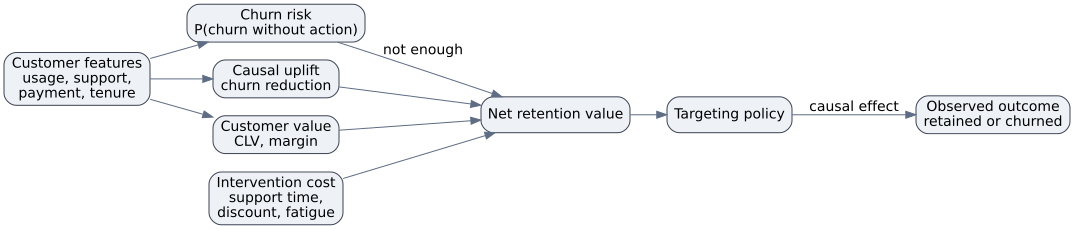

In [2]:
dot = Digraph("retention_decision_graph", format="svg")
dot.attr(rankdir="LR", bgcolor="transparent")
dot.attr("node", shape="box", style="rounded,filled", color="#3B4252", fillcolor="#EEF2F7", fontname="DejaVu Sans")
dot.attr("edge", color="#5E6C84", fontname="DejaVu Sans")

dot.node("features", "Customer features\nusage, support,\npayment, tenure")
dot.node("risk", "Churn risk\nP(churn without action)")
dot.node("uplift", "Causal uplift\nchurn reduction")
dot.node("clv", "Customer value\nCLV, margin")
dot.node("cost", "Intervention cost\nsupport time,\ndiscount, fatigue")
dot.node("net", "Net retention value")
dot.node("policy", "Targeting policy")
dot.node("outcome", "Observed outcome\nretained or churned")

dot.edge("features", "risk")
dot.edge("features", "uplift")
dot.edge("features", "clv")
dot.edge("risk", "net", label="not enough")
dot.edge("uplift", "net")
dot.edge("clv", "net")
dot.edge("cost", "net")
dot.edge("net", "policy")
dot.edge("policy", "outcome", label="causal effect")

dot

Customer lifetime value matters because not every saved customer has the same financial value. Glady, Baesens, and Croux (2009) propose modeling churn using customer lifetime value and emphasize identifying customers for whom a retention action will be profitable. Oskarsdottir, Baesens, and Vanthienen (2018) similarly argue for profit-based retention model selection using individual customer lifetime values.

## 3. Running Example: Subscription Retention Campaign

Imagine a subscription business with a monthly renewal cycle. The company can offer an intervention to customers at risk:

- concierge onboarding call,
- billing support,
- tailored discount,
- plan-fit review,
- proactive troubleshooting.

The intervention has costs:

- staff time,
- discount expense,
- operational load,
- possible contact fatigue.

We simulate a randomized retention experiment where half of eligible customers receive the intervention. Because this is a simulation, we know both potential outcomes. In real retention work, we only observe one outcome per customer.

In [3]:
def simulate_retention_experiment(n=80_000, treatment_share=0.50, seed=404):
    local_rng = np.random.default_rng(seed)

    segments = local_rng.choice(
        ["new_user", "price_sensitive", "power_user", "support_heavy", "premium"],
        size=n,
        p=[0.24, 0.28, 0.22, 0.16, 0.10],
    )
    contract_type = local_rng.choice(["monthly", "annual"], size=n, p=[0.72, 0.28])

    tenure_months = np.clip(local_rng.gamma(shape=2.2, scale=8.0, size=n), 1, 72)
    monthly_value = local_rng.lognormal(mean=np.log(58), sigma=0.45, size=n)
    monthly_value *= np.where(segments == "premium", 1.75, 1.0)
    monthly_value *= np.where(segments == "price_sensitive", 0.82, 1.0)

    usage_days_30 = np.clip(
        local_rng.normal(14, 6, size=n)
        + 5 * (segments == "power_user")
        - 4 * (segments == "new_user")
        - 3 * (segments == "support_heavy"),
        0,
        30,
    )
    support_tickets_90 = local_rng.poisson(
        0.6
        + 1.6 * (segments == "support_heavy")
        + 0.4 * (segments == "new_user"),
        size=n,
    )
    payment_failures = local_rng.binomial(
        2,
        np.clip(0.08 + 0.20 * (segments == "price_sensitive") + 0.10 * (contract_type == "monthly"), 0, 0.65),
        size=n,
    )
    satisfaction = np.clip(
        local_rng.normal(0.58, 0.18, size=n)
        + 0.18 * (segments == "power_user")
        + 0.10 * (segments == "premium")
        - 0.18 * (segments == "support_heavy")
        - 0.10 * payment_failures,
        0,
        1,
    )
    competitor_signal = np.clip(
        local_rng.beta(2.0, 5.0, size=n)
        + 0.22 * (segments == "price_sensitive")
        + 0.14 * (support_tickets_90 >= 3),
        0,
        1,
    )
    email_fatigue = np.clip(
        local_rng.beta(1.8, 4.5, size=n)
        + 0.20 * (segments == "premium")
        + 0.10 * (usage_days_30 > 24),
        0,
        1,
    )

    base_logit = (
        -1.55
        + 1.15 * competitor_signal
        + 0.42 * payment_failures
        + 0.18 * support_tickets_90
        - 1.35 * satisfaction
        - 0.055 * usage_days_30
        - 0.015 * tenure_months
        + 0.42 * (contract_type == "monthly")
        + 0.28 * (segments == "new_user")
        + 0.20 * (segments == "price_sensitive")
    )
    p0 = expit(base_logit)

    # Saveability is highest for moderate-risk customers with fixable problems.
    moderate_risk = np.exp(-((p0 - 0.38) ** 2) / 0.055)
    fixable_problem = (
        0.55 * (support_tickets_90 >= 1)
        + 0.45 * (payment_failures >= 1)
        + 0.35 * (competitor_signal > 0.35)
        + 0.20 * (segments == "new_user")
    )
    save_probability = (
        0.012
        + 0.105 * moderate_risk
        + 0.035 * fixable_problem
        + 0.020 * (segments == "premium")
        - 0.040 * (p0 > 0.78)
    )
    contact_harm = (
        0.010
        + 0.035 * email_fatigue * (p0 < 0.20)
        + 0.018 * (segments == "power_user") * (support_tickets_90 == 0)
    )
    p1 = np.clip(p0 - save_probability + contact_harm, 0.002, 0.96)

    shared_draw = local_rng.uniform(size=n)
    churn0 = (shared_draw < p0).astype(int)
    churn1 = (shared_draw < p1).astype(int)

    treatment = local_rng.binomial(1, treatment_share, size=n)
    observed_churn = np.where(treatment == 1, churn1, churn0)

    expected_remaining_months = np.clip(
        7.5
        + 0.15 * tenure_months
        + 5.0 * satisfaction
        + 4.0 * (contract_type == "annual")
        - 3.0 * competitor_signal,
        3,
        30,
    )
    gross_margin = 0.62
    clv = monthly_value * gross_margin * expected_remaining_months

    intervention_cost = (
        8.0
        + 0.05 * monthly_value
        + 12.0 * (payment_failures >= 1)
        + 7.0 * (support_tickets_90 >= 3)
        + 4.0 * (segments == "premium")
    )

    profit0 = (1 - churn0) * clv
    profit1 = (1 - churn1) * clv - intervention_cost
    observed_profit = np.where(treatment == 1, profit1, profit0)

    df = pd.DataFrame(
        {
            "customer_id": np.arange(n),
            "segment": segments,
            "contract_type": contract_type,
            "tenure_months": tenure_months,
            "monthly_value": monthly_value,
            "usage_days_30": usage_days_30,
            "support_tickets_90": support_tickets_90,
            "payment_failures": payment_failures,
            "satisfaction": satisfaction,
            "competitor_signal": competitor_signal,
            "email_fatigue": email_fatigue,
            "treatment": treatment,
            "churn": observed_churn,
            "observed_profit": observed_profit,
            "clv": clv,
            "intervention_cost": intervention_cost,
            "p_churn0": p0,
            "p_churn1": p1,
            "true_churn_uplift": p0 - p1,
            "expected_profit_uplift": (p0 - p1) * clv - intervention_cost,
            "churn0": churn0,
            "churn1": churn1,
            "profit0": profit0,
            "profit1": profit1,
            "realized_profit_uplift": profit1 - profit0,
        }
    )

    df["latent_response_type"] = np.select(
        [
            (df["churn0"] == 1) & (df["churn1"] == 0),
            (df["churn0"] == 1) & (df["churn1"] == 1),
            (df["churn0"] == 0) & (df["churn1"] == 0),
            (df["churn0"] == 0) & (df["churn1"] == 1),
        ],
        [
            "saved by intervention",
            "not saved",
            "would stay anyway",
            "harmed by contact",
        ],
        default="other",
    )
    return df


retention = simulate_retention_experiment()

display(retention.head())
print(f"Rows: {len(retention):,}")
print(f"Treatment share: {retention['treatment'].mean():.1%}")
print(f"Observed churn rate: {retention['churn'].mean():.1%}")
print(f"Mean CLV: {dollars(retention['clv'].mean(), 0)}")
print(f"Mean intervention cost if contacted: {dollars(retention['intervention_cost'].mean(), 0)}")

,customer_id,segment,contract_type,tenure_months,monthly_value,usage_days_30,support_tickets_90,payment_failures,satisfaction,competitor_signal,...,p_churn0,p_churn1,true_churn_uplift,expected_profit_uplift,churn0,churn1,profit0,profit1,realized_profit_uplift,latent_response_type
0,0,price_sensitive,annual,14.047458,22.247393,15.689335,1,0,0.390349,0.617586,...,0.113008,0.062117,0.050892,0.508876,1,1,0.000000,-9.112370,-9.112370,not saved
1,1,price_sensitive,monthly,7.139827,31.844243,11.305244,0,2,0.387166,0.478387,...,0.311865,0.185364,0.126501,1.064794,1,1,0.000000,-21.592212,-21.592212,not saved
2,2,price_sensitive,monthly,40.326813,33.588314,14.649203,0,0,0.388226,0.412206,...,0.083886,0.049810,0.034077,0.435416,0,0,296.826395,287.146979,-9.679416,would stay anyway
3,3,power_user,annual,7.051698,87.023121,17.448516,1,0,0.682430,0.440927,...,0.054699,0.009692,0.045007,23.216791,0,0,790.275768,777.924612,-12.351156,would stay anyway
4,4,price_sensitive,monthly,6.429099,104.297991,18.328131,0,0,0.407344,0.581802,...,0.128384,0.091274,0.037109,7.795775,0,0,566.183759,552.968859,-13.214900,would stay anyway


Rows: 80,000
Treatment share: 49.9%
Observed churn rate: 10.2%
Mean CLV: $531
Mean intervention cost if contacted: $17


The simulation creates four latent response types:

- customers saved by the intervention,
- customers who would churn even with intervention,
- customers who would stay anyway,
- customers harmed by unnecessary contact.

In real data these types are latent because we never observe both potential outcomes. They are included here only to make the targeting problem visible.

In [4]:
type_summary = (
    retention.groupby("latent_response_type")
    .agg(
        customers=("customer_id", "size"),
        share=("customer_id", lambda x: len(x) / len(retention)),
        avg_p_churn0=("p_churn0", "mean"),
        avg_true_churn_uplift=("true_churn_uplift", "mean"),
        avg_expected_profit_uplift=("expected_profit_uplift", "mean"),
        avg_clv=("clv", "mean"),
    )
    .reset_index()
    .sort_values("share", ascending=False)
)

display(
    styled_table(
        type_summary,
        pct_cols=["share", "avg_p_churn0", "avg_true_churn_uplift"],
        money_cols=["avg_expected_profit_uplift", "avg_clv"],
    )
)

,latent_response_type,customers,share,avg_p_churn0,avg_true_churn_uplift,avg_expected_profit_uplift,avg_clv
3,would stay anyway,69628,87.03%,12.09%,4.94%,$7.58,$541
1,not saved,6022,7.53%,19.51%,7.61%,$13.00,$451
2,saved by intervention,4295,5.37%,18.81%,8.18%,$16.66,$473
0,harmed by contact,55,0.07%,3.23%,-1.66%,$-20.65,$570


Already we can see why retention is not a simple classification problem. The intervention can be profitable for some customers, wasteful for others, and harmful for a small subset.

## 4. Experiment Balance and Average Treatment Effect

Because treatment is randomized, pre-treatment features should be balanced across treatment groups. Balance is not proof of correct execution, but imbalance is a warning sign.

In [5]:
balance = (
    retention.groupby("treatment")
    .agg(
        customers=("customer_id", "size"),
        monthly_value=("monthly_value", "mean"),
        tenure_months=("tenure_months", "mean"),
        usage_days_30=("usage_days_30", "mean"),
        support_tickets_90=("support_tickets_90", "mean"),
        payment_failures=("payment_failures", "mean"),
        satisfaction=("satisfaction", "mean"),
        competitor_signal=("competitor_signal", "mean"),
        clv=("clv", "mean"),
    )
    .rename(index={0: "Control", 1: "Retention intervention"})
    .reset_index(names="group")
)

display(
    styled_table(
        balance,
        money_cols=["monthly_value", "clv"],
        num_cols=["tenure_months", "usage_days_30", "support_tickets_90", "payment_failures", "satisfaction", "competitor_signal"],
    )
)

,group,customers,monthly_value,tenure_months,usage_days_30,support_tickets_90,payment_failures,satisfaction,competitor_signal,clv
0,Control,40067,$65.86,17.505,13.672,0.955,0.417,0.559,0.360,$532
1,Retention intervention,39933,$65.43,17.561,13.697,0.950,0.419,0.558,0.360,$529


In [6]:
def ate_binary_reduction(df, outcome_col="churn", treatment_col="treatment"):
    treated = df[treatment_col].eq(1)
    y_t = df.loc[treated, outcome_col]
    y_c = df.loc[~treated, outcome_col]
    # For churn, positive means treatment reduces churn.
    effect = y_c.mean() - y_t.mean()
    se = np.sqrt(y_t.var(ddof=1) / len(y_t) + y_c.var(ddof=1) / len(y_c))
    return effect, effect - 1.96 * se, effect + 1.96 * se


def ate_profit(df, outcome_col="observed_profit", treatment_col="treatment"):
    treated = df[treatment_col].eq(1)
    y_t = df.loc[treated, outcome_col]
    y_c = df.loc[~treated, outcome_col]
    effect = y_t.mean() - y_c.mean()
    se = np.sqrt(y_t.var(ddof=1) / len(y_t) + y_c.var(ddof=1) / len(y_c))
    return effect, effect - 1.96 * se, effect + 1.96 * se


churn_effect, churn_lo, churn_hi = ate_binary_reduction(retention)
profit_effect, profit_lo, profit_hi = ate_profit(retention)

ate_readout = pd.DataFrame(
    {
        "metric": [
            "Control churn rate",
            "Treatment churn rate",
            "Churn reduction ATE",
            "Churn reduction CI low",
            "Churn reduction CI high",
            "Profit ATE per customer",
            "Profit ATE CI low",
            "Profit ATE CI high",
        ],
        "value": [
            retention.loc[retention["treatment"].eq(0), "churn"].mean(),
            retention.loc[retention["treatment"].eq(1), "churn"].mean(),
            churn_effect,
            churn_lo,
            churn_hi,
            profit_effect,
            profit_lo,
            profit_hi,
        ],
    }
)

display(ate_readout)
print(f"True average churn reduction: {retention['true_churn_uplift'].mean():.2%}")
print(f"True average expected net value if everyone is contacted: {dollars(retention['expected_profit_uplift'].mean(), 2)} per customer")

,metric,value
0,Control churn rate,0.127337
1,Treatment churn rate,0.076428
2,Churn reduction ATE,0.050909
3,Churn reduction CI low,0.046732
4,Churn reduction CI high,0.055085
5,Profit ATE per customer,4.173300
6,Profit ATE CI low,-0.721662
7,Profit ATE CI high,9.068262


True average churn reduction: 5.31%
True average expected net value if everyone is contacted: $8.45 per customer


The average treatment effect answers whether the intervention works on average. The targeting question is more specific:

> Among all eligible customers, who should receive the intervention?

An average effect can be positive while broad targeting is still inefficient.

## 5. Churn-Risk Model

A standard retention workflow begins with churn prediction. We will train a model on the randomized control group to estimate churn risk without intervention:

$$
\hat{r}(x) \approx P(Y(0)=1\mid X=x)
$$

This is a valid and useful model, but it estimates risk, not saveability.

In [7]:
feature_cols = [
    "segment",
    "contract_type",
    "tenure_months",
    "monthly_value",
    "usage_days_30",
    "support_tickets_90",
    "payment_failures",
    "satisfaction",
    "competitor_signal",
    "email_fatigue",
]
categorical_cols = ["segment", "contract_type"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]


def make_classifier(seed=1, max_iter=140):
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
            ("num", "passthrough", numeric_cols),
        ]
    )
    model = HistGradientBoostingClassifier(
        max_iter=max_iter,
        learning_rate=0.055,
        max_leaf_nodes=24,
        random_state=seed,
    )
    return Pipeline([("preprocess", preprocess), ("model", model)])


train_df, test_df = train_test_split(
    retention,
    test_size=0.40,
    random_state=17,
    stratify=retention["treatment"],
)

control_train = train_df.query("treatment == 0")
control_test = test_df.query("treatment == 0")

risk_model = make_classifier(seed=11)
risk_model.fit(control_train[feature_cols], control_train["churn"])

test_df = test_df.copy()
test_df["risk_score"] = risk_model.predict_proba(test_df[feature_cols])[:, 1]

auc_control = roc_auc_score(control_test["churn"], risk_model.predict_proba(control_test[feature_cols])[:, 1])
print(f"Control-group churn-risk AUC: {auc_control:.3f}")

Control-group churn-risk AUC: 0.699


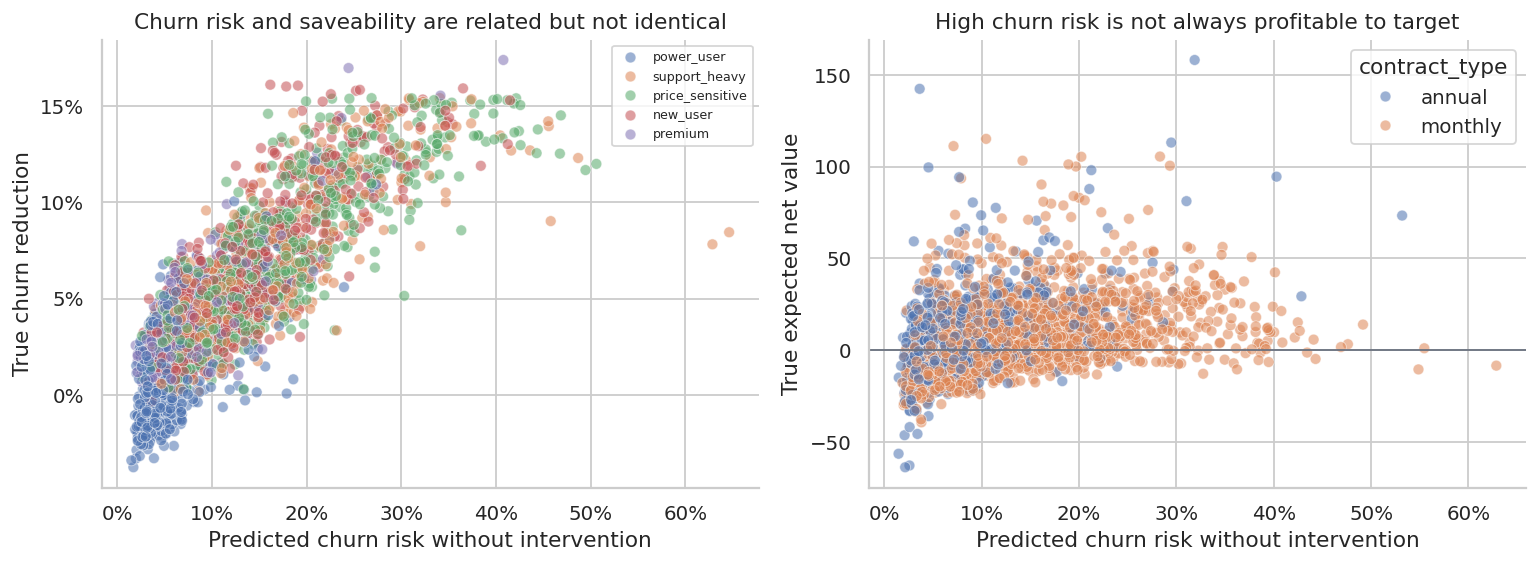

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=test_df.sample(2500, random_state=3),
    x="risk_score",
    y="true_churn_uplift",
    hue="segment",
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Churn risk and saveability are related but not identical")
axes[0].set_xlabel("Predicted churn risk without intervention")
axes[0].set_ylabel("True churn reduction")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[0].legend(fontsize=7, title="")

sns.scatterplot(
    data=test_df.sample(2500, random_state=5),
    x="risk_score",
    y="expected_profit_uplift",
    hue="contract_type",
    alpha=0.55,
    ax=axes[1],
)
axes[1].axhline(0, color="#6B7280", linewidth=1)
axes[1].set_title("High churn risk is not always profitable to target")
axes[1].set_xlabel("Predicted churn risk without intervention")
axes[1].set_ylabel("True expected net value")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

plt.tight_layout()
plt.show()

A model can rank churn risk well and still be suboptimal for targeting. The highest-risk customers may include many customers who are already too far gone, while moderately risky customers with fixable problems may be more responsive.

## 6. Uplift Modeling with a Two-Model Approach

A simple uplift method trains separate outcome models for treated and control customers:

$$
\hat{\mu}_0(x) = \widehat{E}[Y\mid W=0,X=x]
$$

$$
\hat{\mu}_1(x) = \widehat{E}[Y\mid W=1,X=x]
$$

For churn reduction:

$$
\hat{\tau}(x) = \hat{\mu}_0(x)-\hat{\mu}_1(x)
$$

This is often called a two-model or T-learner approach. It is easy to explain to stakeholders and works naturally with randomized retention data.

In [9]:
control_model = make_classifier(seed=21)
treated_model = make_classifier(seed=22)

control_model.fit(train_df.query("treatment == 0")[feature_cols], train_df.query("treatment == 0")["churn"])
treated_model.fit(train_df.query("treatment == 1")[feature_cols], train_df.query("treatment == 1")["churn"])

test_df["p0_hat"] = control_model.predict_proba(test_df[feature_cols])[:, 1]
test_df["p1_hat"] = treated_model.predict_proba(test_df[feature_cols])[:, 1]
test_df["uplift_hat"] = test_df["p0_hat"] - test_df["p1_hat"]
test_df["net_value_hat"] = test_df["uplift_hat"] * test_df["clv"] - test_df["intervention_cost"]

uplift_quality = pd.DataFrame(
    {
        "metric": [
            "Correlation: predicted uplift vs true uplift",
            "Correlation: predicted net value vs true net value",
            "Mean predicted uplift",
            "Mean true uplift",
            "Mean predicted net value",
            "Mean true net value",
        ],
        "value": [
            test_df[["uplift_hat", "true_churn_uplift"]].corr().iloc[0, 1],
            test_df[["net_value_hat", "expected_profit_uplift"]].corr().iloc[0, 1],
            test_df["uplift_hat"].mean(),
            test_df["true_churn_uplift"].mean(),
            test_df["net_value_hat"].mean(),
            test_df["expected_profit_uplift"].mean(),
        ],
    }
)

display(uplift_quality)

,metric,value
0,Correlation: predicted uplift vs true uplift,0.617777
1,Correlation: predicted net value vs true net v...,0.501015
2,Mean predicted uplift,0.049698
3,Mean true uplift,0.053243
4,Mean predicted net value,6.704789
5,Mean true net value,8.540971


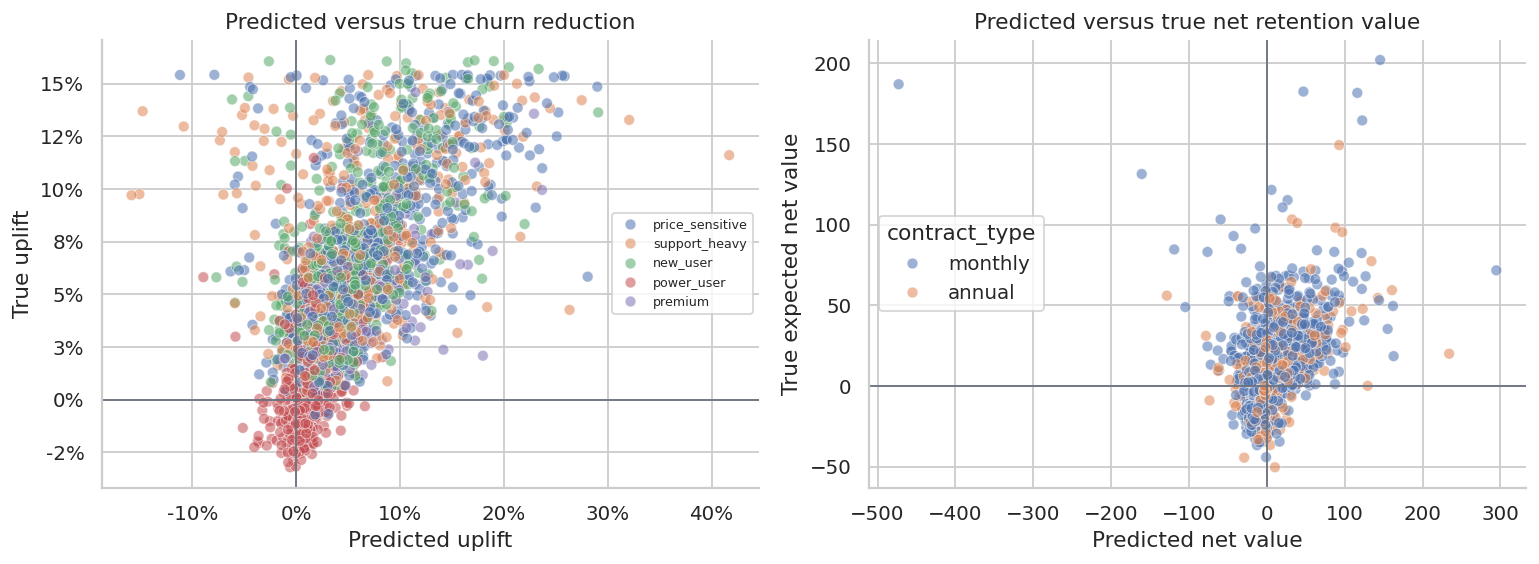

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=test_df.sample(2800, random_state=8),
    x="uplift_hat",
    y="true_churn_uplift",
    hue="segment",
    alpha=0.55,
    ax=axes[0],
)
axes[0].axhline(0, color="#6B7280", linewidth=1)
axes[0].axvline(0, color="#6B7280", linewidth=1)
axes[0].set_title("Predicted versus true churn reduction")
axes[0].set_xlabel("Predicted uplift")
axes[0].set_ylabel("True uplift")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
axes[0].legend(fontsize=7, title="")

sns.scatterplot(
    data=test_df.sample(2800, random_state=9),
    x="net_value_hat",
    y="expected_profit_uplift",
    hue="contract_type",
    alpha=0.55,
    ax=axes[1],
)
axes[1].axhline(0, color="#6B7280", linewidth=1)
axes[1].axvline(0, color="#6B7280", linewidth=1)
axes[1].set_title("Predicted versus true net retention value")
axes[1].set_xlabel("Predicted net value")
axes[1].set_ylabel("True expected net value")

plt.tight_layout()
plt.show()

The uplift model does not need to be perfect to be useful. It needs to rank customers better than simpler targeting rules under business constraints.

## 7. Policy Evaluation: Who Should We Contact?

We now compare several targeting policies on the test set:

- contact nobody,
- contact everybody,
- contact the top 25% by churn risk,
- contact the top 25% by predicted uplift,
- contact the top 25% by predicted net value,
- contact customers with positive predicted net value.

Because we simulated the true potential outcomes, we can evaluate each policy using true expected net value. In real life, this comparison would be estimated from randomized validation data or an online experiment.

In [11]:
def evaluate_policy(df, contact_mask, label):
    contacted = df.loc[contact_mask]
    total_net_value = contacted["expected_profit_uplift"].sum()
    saved_probability = contacted["true_churn_uplift"].sum()
    total_cost = contacted["intervention_cost"].sum()
    gross_saved_clv = (contacted["true_churn_uplift"] * contacted["clv"]).sum()
    return {
        "policy": label,
        "customers_contacted": int(contact_mask.sum()),
        "contact_share": contact_mask.mean(),
        "expected_saves": saved_probability,
        "gross_saved_clv": gross_saved_clv,
        "intervention_cost": total_cost,
        "expected_net_value": total_net_value,
        "net_value_per_contact": total_net_value / max(contact_mask.sum(), 1),
    }


def top_share_mask(df, score_col, share=0.25):
    cutoff_n = int(np.ceil(len(df) * share))
    selected_index = df.sort_values(score_col, ascending=False).head(cutoff_n).index
    return df.index.isin(selected_index)


policy_rows = []
policy_rows.append(evaluate_policy(test_df, np.zeros(len(test_df), dtype=bool), "Contact nobody"))
policy_rows.append(evaluate_policy(test_df, np.ones(len(test_df), dtype=bool), "Contact everybody"))
policy_rows.append(evaluate_policy(test_df, top_share_mask(test_df, "risk_score", 0.25), "Top 25% by churn risk"))
policy_rows.append(evaluate_policy(test_df, top_share_mask(test_df, "uplift_hat", 0.25), "Top 25% by uplift"))
policy_rows.append(evaluate_policy(test_df, top_share_mask(test_df, "net_value_hat", 0.25), "Top 25% by net value"))
policy_rows.append(evaluate_policy(test_df, test_df["net_value_hat"].gt(0).to_numpy(), "Predicted positive net value"))

policy_eval = pd.DataFrame(policy_rows)

display(
    styled_table(
        policy_eval,
        pct_cols=["contact_share"],
        money_cols=["gross_saved_clv", "intervention_cost", "expected_net_value", "net_value_per_contact"],
        num_cols=["expected_saves"],
    )
)

,policy,customers_contacted,contact_share,expected_saves,gross_saved_clv,intervention_cost,expected_net_value,net_value_per_contact
0,Contact nobody,0,0.00%,0.000,$0.00,$0.00,$0.00,$0.00
1,Contact everybody,32000,100.00%,"1,703.762","$808,644","$535,333","$273,311",$8.54
2,Top 25% by churn risk,8000,25.00%,832.043,"$323,326","$164,143","$159,183",$19.90
3,Top 25% by uplift,8000,25.00%,743.733,"$301,724","$163,379","$138,345",$17.29
4,Top 25% by net value,8000,25.00%,595.412,"$354,269","$153,653","$200,615",$25.08
5,Predicted positive net value,17386,54.33%,"1,116.903","$577,097","$299,597","$277,500",$15.96


This table is the heart of retention targeting. Churn-risk targeting can contact many customers who look dangerous but are not actually responsive enough to justify the intervention cost. Net-value targeting combines uplift, CLV, and cost.

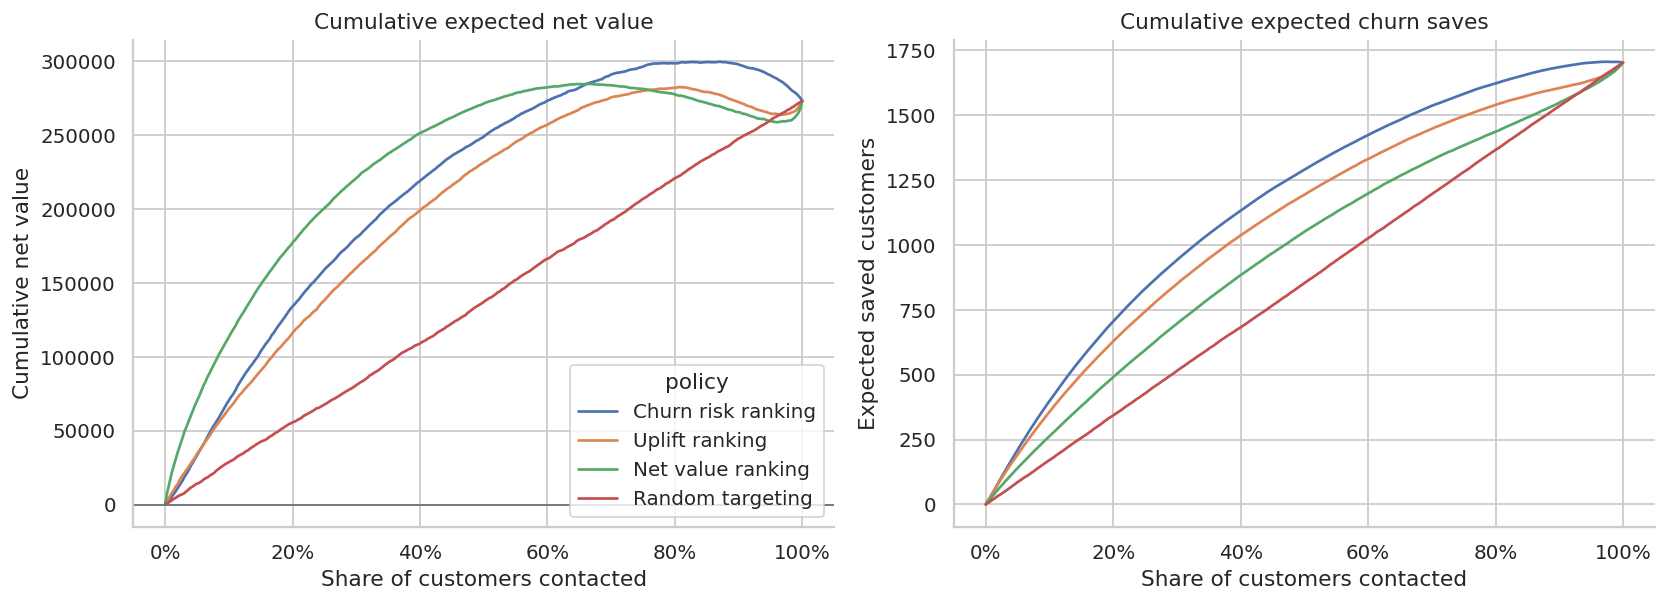

In [12]:
def cumulative_value_curve(df, score_col, label):
    ordered = df.sort_values(score_col, ascending=False).copy()
    ordered["cum_net_value"] = ordered["expected_profit_uplift"].cumsum()
    ordered["cum_saves"] = ordered["true_churn_uplift"].cumsum()
    ordered["contact_share"] = np.arange(1, len(ordered) + 1) / len(ordered)
    sample = ordered.iloc[np.linspace(0, len(ordered) - 1, 300).astype(int)].copy()
    sample["policy"] = label
    return sample[["contact_share", "cum_net_value", "cum_saves", "policy"]]


random_df = test_df.copy()
random_df["random_score"] = rng.normal(size=len(random_df))

curves = pd.concat(
    [
        cumulative_value_curve(test_df, "risk_score", "Churn risk ranking"),
        cumulative_value_curve(test_df, "uplift_hat", "Uplift ranking"),
        cumulative_value_curve(test_df, "net_value_hat", "Net value ranking"),
        cumulative_value_curve(random_df, "random_score", "Random targeting"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.lineplot(data=curves, x="contact_share", y="cum_net_value", hue="policy", ax=axes[0])
axes[0].axhline(0, color="#6B7280", linewidth=1)
axes[0].set_title("Cumulative expected net value")
axes[0].set_xlabel("Share of customers contacted")
axes[0].set_ylabel("Cumulative net value")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.lineplot(data=curves, x="contact_share", y="cum_saves", hue="policy", ax=axes[1], legend=False)
axes[1].set_title("Cumulative expected churn saves")
axes[1].set_xlabel("Share of customers contacted")
axes[1].set_ylabel("Expected saved customers")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

plt.tight_layout()
plt.show()

The best policy is not necessarily the one that saves the most customers. If it saves low-value customers at high cost, it can be less profitable than a smaller, sharper targeting rule.

## 8. Segment-Level Treatment Effects

Stakeholders often want to know where the intervention works. We can estimate treatment effects by segment.

Within a randomized experiment:

$$
\hat{\tau}_g =
\bar{Y}_{g,W=0} - \bar{Y}_{g,W=1}
$$

for churn reduction in segment $g$.

In [13]:
segment_rows = []
for segment, g in retention.groupby("segment"):
    effect, lo, hi = ate_binary_reduction(g)
    profit_eff, profit_lo_g, profit_hi_g = ate_profit(g)
    segment_rows.append(
        {
            "segment": segment,
            "customers": len(g),
            "control_churn": g.loc[g["treatment"].eq(0), "churn"].mean(),
            "treatment_churn": g.loc[g["treatment"].eq(1), "churn"].mean(),
            "estimated_churn_reduction": effect,
            "ci_low": lo,
            "ci_high": hi,
            "profit_ate_per_customer": profit_eff,
            "true_mean_net_value": g["expected_profit_uplift"].mean(),
        }
    )

segment_effects = pd.DataFrame(segment_rows).sort_values("estimated_churn_reduction", ascending=False)

display(
    styled_table(
        segment_effects,
        pct_cols=["control_churn", "treatment_churn", "estimated_churn_reduction", "ci_low", "ci_high"],
        money_cols=["profit_ate_per_customer", "true_mean_net_value"],
    )
)

,segment,customers,control_churn,treatment_churn,estimated_churn_reduction,ci_low,ci_high,profit_ate_per_customer,true_mean_net_value
3,price_sensitive,22399,16.25%,9.43%,6.81%,5.94%,7.69%,$7.36,$7.76
4,support_heavy,12825,16.91%,10.56%,6.35%,5.17%,7.54%,$9.33,$14.01
0,new_user,19158,14.20%,8.61%,5.60%,4.70%,6.49%,$15.18,$15.65
2,premium,7971,8.28%,3.87%,4.41%,3.37%,5.46%,$-8.59,$18.85
1,power_user,17647,5.58%,3.96%,1.63%,1.00%,2.26%,$-12.51,$-7.22


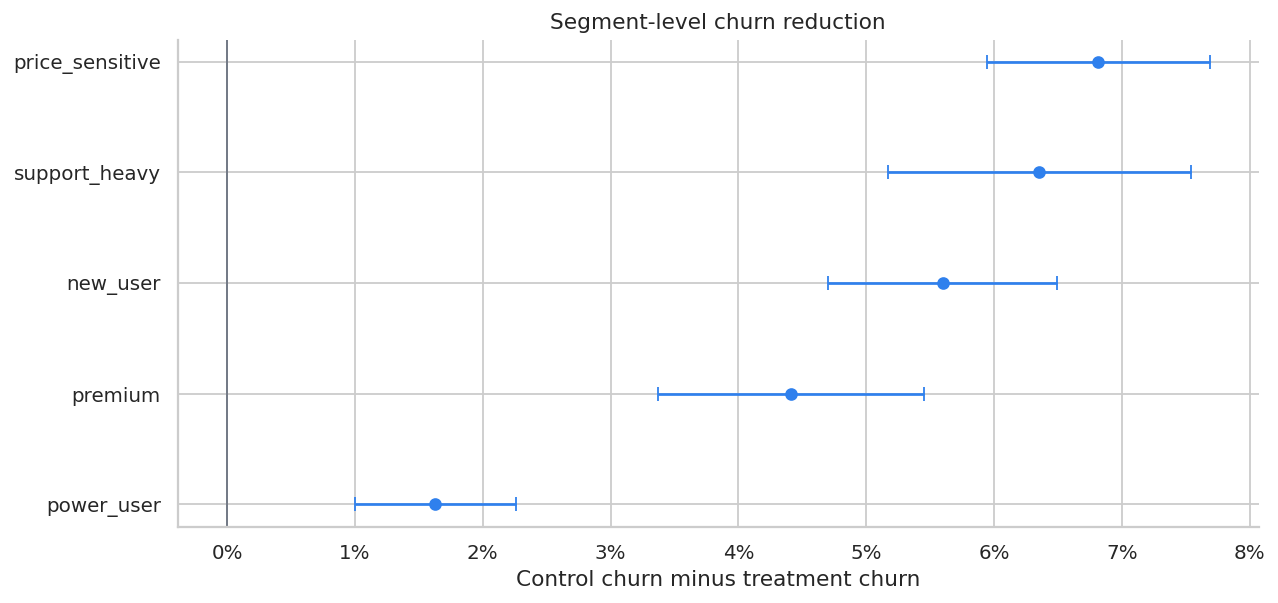

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_segments = segment_effects.sort_values("estimated_churn_reduction")
ax.errorbar(
    plot_segments["estimated_churn_reduction"],
    plot_segments["segment"],
    xerr=[
        plot_segments["estimated_churn_reduction"] - plot_segments["ci_low"],
        plot_segments["ci_high"] - plot_segments["estimated_churn_reduction"],
    ],
    fmt="o",
    color="#2F80ED",
    capsize=4,
)
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_title("Segment-level churn reduction")
ax.set_xlabel("Control churn minus treatment churn")
ax.xaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
plt.tight_layout()
plt.show()

Segment analysis is useful for communication, but it is coarse. A policy can perform better by ranking customers within each segment using predicted net value.

## 9. Capacity Constraints

Retention teams often have limited operational capacity. Suppose the support team can contact only 6,000 customers this cycle. The right policy is not "contact all positive customers" if capacity is binding. It is "contact the highest expected net value customers subject to capacity."

In [15]:
capacity = 6_000
capacity_df = test_df.copy()

capacity_policies = {
    "Top capacity by churn risk": "risk_score",
    "Top capacity by uplift": "uplift_hat",
    "Top capacity by net value": "net_value_hat",
}

capacity_rows = []
for label, score_col in capacity_policies.items():
    selected = capacity_df.sort_values(score_col, ascending=False).head(capacity).index
    mask = capacity_df.index.isin(selected)
    capacity_rows.append(evaluate_policy(capacity_df, mask, label))

capacity_eval = pd.DataFrame(capacity_rows)

display(
    styled_table(
        capacity_eval,
        pct_cols=["contact_share"],
        money_cols=["gross_saved_clv", "intervention_cost", "expected_net_value", "net_value_per_contact"],
        num_cols=["expected_saves"],
    )
)

,policy,customers_contacted,contact_share,expected_saves,gross_saved_clv,intervention_cost,expected_net_value,net_value_per_contact
0,Top capacity by churn risk,6000,18.75%,671.913,"$252,931","$126,281","$126,650",$21.11
1,Top capacity by uplift,6000,18.75%,597.626,"$236,405","$126,619","$109,785",$18.30
2,Top capacity by net value,6000,18.75%,463.766,"$289,957","$119,300","$170,658",$28.44


This is the operational form of causal targeting. A model is only valuable if it changes the action list under real constraints.

## 10. Sensitivity to Intervention Cost

Retention offers are not free. If discount size, support time, or incentive cost increases, the optimal contact depth changes.

In [16]:
cost_multipliers = np.linspace(0.5, 2.0, 16)
sensitivity_rows = []

for mult in cost_multipliers:
    temp = test_df.copy()
    temp["expected_profit_uplift_cost_scenario"] = (
        temp["true_churn_uplift"] * temp["clv"] - mult * temp["intervention_cost"]
    )
    temp["net_value_hat_cost_scenario"] = temp["uplift_hat"] * temp["clv"] - mult * temp["intervention_cost"]
    selected = temp["net_value_hat_cost_scenario"].gt(0)
    sensitivity_rows.append(
        {
            "cost_multiplier": mult,
            "contact_share": selected.mean(),
            "expected_net_value": temp.loc[selected, "expected_profit_uplift_cost_scenario"].sum(),
            "expected_saves": temp.loc[selected, "true_churn_uplift"].sum(),
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)

display(styled_table(sensitivity, pct_cols=["contact_share"], money_cols=["expected_net_value"], num_cols=["expected_saves"]))

,cost_multiplier,contact_share,expected_net_value,expected_saves
0,0.500000,74.41%,"$493,239","1,429.249"
1,0.600000,70.32%,"$444,203","1,371.409"
2,0.700000,66.33%,"$397,831","1,312.538"
3,0.800000,62.38%,"$354,687","1,250.150"
4,0.900000,58.27%,"$314,558","1,184.324"
5,1.000000,54.33%,"$277,500","1,116.903"
6,1.100000,50.62%,"$242,743","1,052.824"
7,1.200000,47.11%,"$211,139",988.616
8,1.300000,43.64%,"$182,280",925.450
9,1.400000,40.40%,"$156,303",862.636


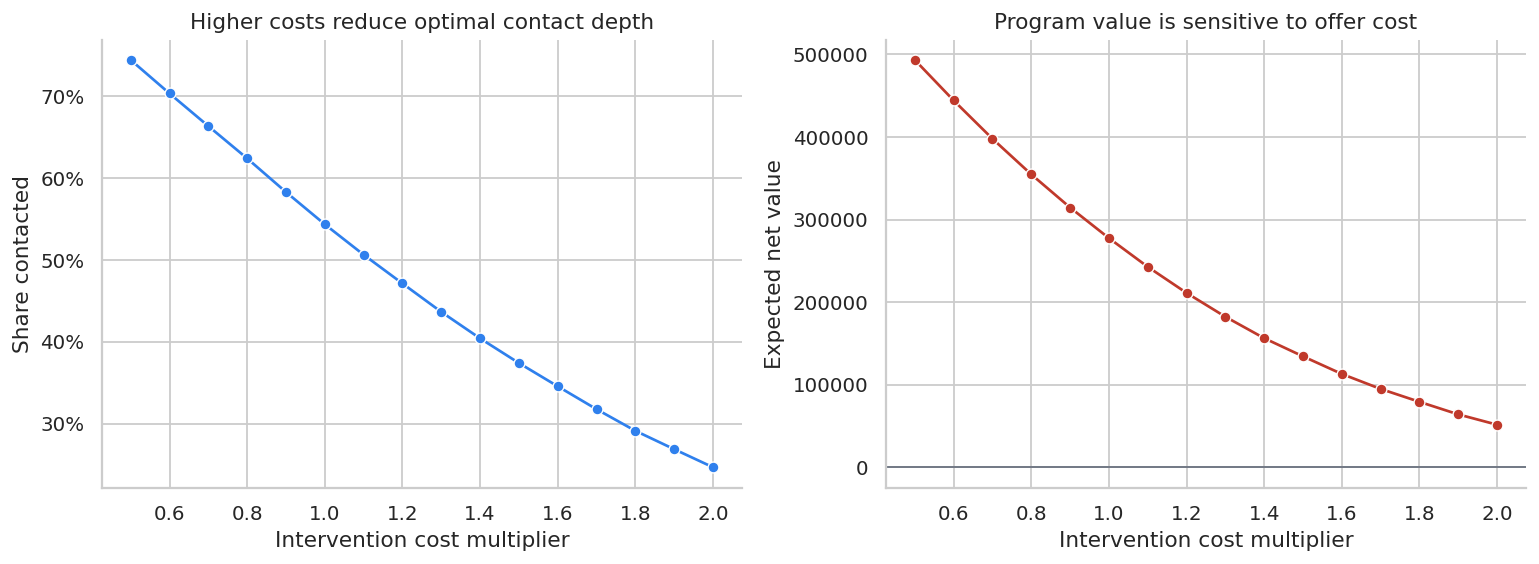

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(data=sensitivity, x="cost_multiplier", y="contact_share", marker="o", ax=axes[0], color="#2F80ED")
axes[0].set_title("Higher costs reduce optimal contact depth")
axes[0].set_xlabel("Intervention cost multiplier")
axes[0].set_ylabel("Share contacted")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.lineplot(data=sensitivity, x="cost_multiplier", y="expected_net_value", marker="o", ax=axes[1], color="#C0392B")
axes[1].axhline(0, color="#6B7280", linewidth=1)
axes[1].set_title("Program value is sensitive to offer cost")
axes[1].set_xlabel("Intervention cost multiplier")
axes[1].set_ylabel("Expected net value")

plt.tight_layout()
plt.show()

Sensitivity analysis is especially important when the treatment includes a discount. The treatment effect may be real, but the offer can still be too expensive.

## 11. Common Retention Threats

Retention interventions can fail for statistical and operational reasons.

In [18]:
threats = pd.DataFrame(
    [
        {
            "threat": "Risk targeting mistaken for uplift targeting",
            "symptom": "The team contacts the highest-risk customers only.",
            "diagnostic": "Compare churn-risk, uplift, and net-value targeting curves.",
            "mitigation": "Randomized holdout and uplift modeling.",
        },
        {
            "threat": "Contact fatigue",
            "symptom": "Low-risk customers complain or churn after unnecessary outreach.",
            "diagnostic": "Measure unsubscribe, complaint, and future engagement guardrails.",
            "mitigation": "Suppress low net-value customers and cap contact frequency.",
        },
        {
            "threat": "Offer leakage",
            "symptom": "Customers learn to threaten churn to receive discounts.",
            "diagnostic": "Track repeated offer exposure and strategic downgrade behavior.",
            "mitigation": "Randomized offer rules, eligibility windows, and non-discount interventions.",
        },
        {
            "threat": "Short outcome window",
            "symptom": "The intervention delays churn but does not improve long-term retention.",
            "diagnostic": "Track 30, 60, 90, and 180-day retention.",
            "mitigation": "Use cumulative CLV outcomes and delayed guardrails.",
        },
        {
            "threat": "Capacity bottleneck",
            "symptom": "The model recommends more contacts than the team can handle.",
            "diagnostic": "Evaluate value under contact capacity constraints.",
            "mitigation": "Rank by expected net value, not binary risk.",
        },
        {
            "threat": "Bad CLV estimates",
            "symptom": "Saved customers do not generate the expected value.",
            "diagnostic": "Backtest CLV calibration by segment.",
            "mitigation": "Use conservative CLV, sensitivity analysis, and finance review.",
        },
        {
            "threat": "Unobserved treatment variation",
            "symptom": "Some agents deliver better interventions than others.",
            "diagnostic": "Log intervention type, agent, script, and completion status.",
            "mitigation": "Standardize treatment or model treatment variants separately.",
        },
    ]
)

display(threats)

,threat,symptom,diagnostic,mitigation
0,Risk targeting mistaken for uplift targeting,The team contacts the highest-risk customers o...,"Compare churn-risk, uplift, and net-value targ...",Randomized holdout and uplift modeling.
1,Contact fatigue,Low-risk customers complain or churn after unn...,"Measure unsubscribe, complaint, and future eng...",Suppress low net-value customers and cap conta...
2,Offer leakage,Customers learn to threaten churn to receive d...,Track repeated offer exposure and strategic do...,"Randomized offer rules, eligibility windows, a..."
3,Short outcome window,The intervention delays churn but does not imp...,"Track 30, 60, 90, and 180-day retention.",Use cumulative CLV outcomes and delayed guardr...
4,Capacity bottleneck,The model recommends more contacts than the te...,Evaluate value under contact capacity constrai...,"Rank by expected net value, not binary risk."
5,Bad CLV estimates,Saved customers do not generate the expected v...,Backtest CLV calibration by segment.,"Use conservative CLV, sensitivity analysis, an..."
6,Unobserved treatment variation,Some agents deliver better interventions than ...,"Log intervention type, agent, script, and comp...",Standardize treatment or model treatment varia...


## 12. Decision Memo Template

Below is a compact retention readout for the capacity-constrained targeting policy.

In [19]:
best_capacity = capacity_eval.sort_values("expected_net_value", ascending=False).iloc[0]
selected_idx = (
    test_df.sort_values("net_value_hat", ascending=False)
    .head(capacity)
    .index
)
selected_customers = test_df.loc[selected_idx]

gross_saved_clv = (selected_customers["true_churn_uplift"] * selected_customers["clv"]).sum()
program_cost = selected_customers["intervention_cost"].sum()
program_net = selected_customers["expected_profit_uplift"].sum()
expected_saves = selected_customers["true_churn_uplift"].sum()
roi = gross_saved_clv / program_cost

memo = f'''
### Retention Intervention Readout

**Decision:** Which customers should receive the next-cycle retention intervention.

**Design:** Randomized retention campaign used to estimate churn reduction and net retention value.

**Primary estimand:** Customer-level expected net value: churn reduction multiplied by CLV, minus intervention cost.

**Recommended policy:** Contact the top {capacity:,} customers by predicted net value.

**Expected saved customers:** {expected_saves:,.0f}.

**Gross saved CLV:** {dollars(gross_saved_clv, 0)}.

**Intervention cost:** {dollars(program_cost, 0)}.

**Expected net value:** {dollars(program_net, 0)}.

**Gross value-to-cost ratio:** {roi:,.2f}x.

**Recommendation:** Use net-value targeting for the next campaign cycle, maintain a randomized holdout, and monitor contact fatigue, offer leakage, and delayed retention.

**Caveats:** The policy depends on CLV calibration, intervention consistency, and stable customer behavior across campaign cycles.
'''

display(Markdown(memo))


### Retention Intervention Readout

**Decision:** Which customers should receive the next-cycle retention intervention.

**Design:** Randomized retention campaign used to estimate churn reduction and net retention value.

**Primary estimand:** Customer-level expected net value: churn reduction multiplied by CLV, minus intervention cost.

**Recommended policy:** Contact the top 6,000 customers by predicted net value.

**Expected saved customers:** 464.

**Gross saved CLV:** $289,957.

**Intervention cost:** $119,300.

**Expected net value:** $170,658.

**Gross value-to-cost ratio:** 2.43x.

**Recommendation:** Use net-value targeting for the next campaign cycle, maintain a randomized holdout, and monitor contact fatigue, offer leakage, and delayed retention.

**Caveats:** The policy depends on CLV calibration, intervention consistency, and stable customer behavior across campaign cycles.


A good retention memo does not say "the churn model has high AUC, so ship it." It says which action list changes, what value is expected, how uncertainty is handled, and which operational risks remain.

## 13. Practical Workflow

A professional retention-causal workflow usually follows this sequence:

1. Define churn, retention, and value windows.
2. Randomize a holdout for each intervention type.
3. Log eligibility, assignment, delivery, completion, cost, and outcome.
4. Estimate the average treatment effect for program-level accountability.
5. Estimate heterogeneous uplift for targeting.
6. Convert uplift into expected net value using CLV and intervention cost.
7. Evaluate targeting curves under capacity constraints.
8. Keep a persistent holdout to monitor drift and long-term effects.
9. Track guardrails: complaints, contact fatigue, offer leakage, downgrades, and delayed churn.
10. Convert the analysis into an operational contact list and decision memo.

## Hands-On Extensions

Try extending this notebook in the following ways:

- Add multiple retention treatments, such as call, discount, billing support, and plan review.
- Estimate treatment-specific uplift and choose the best treatment per customer.
- Add delayed churn outcomes at 30, 60, and 90 days.
- Use survival analysis for time-to-churn rather than binary churn.
- Add fairness constraints across customer segments.
- Backtest CLV calibration and show how targeting changes under conservative CLV.
- Compare the T-learner with causal forests or doubly robust learners.

## Key Takeaways

- Churn prediction estimates who is likely to leave; uplift estimates who can be saved.
- High churn risk is not the same as high retention value.
- The correct targeting score combines treatment effect, CLV, intervention cost, and operational constraints.
- A randomized holdout is the cleanest way to estimate retention intervention effects.
- Uplift models should be evaluated by targeting value curves, not only prediction metrics.
- Capacity constraints turn causal estimates into ranked contact lists.
- Retention programs need guardrails for contact fatigue, offer leakage, and delayed churn.

## References

Glady, N., Baesens, B., & Croux, C. (2009). Modeling churn using customer lifetime value. *European Journal of Operational Research, 197*(1), 402-411. https://doi.org/10.1016/j.ejor.2008.06.027

Guelman, L., Guillen, M., & Perez Marin, A. M. (2012). Random forests for uplift modeling: An insurance customer retention case. In *Modeling and Simulation in Engineering, Economics and Management* (pp. 123-133). Springer. https://doi.org/10.1007/978-3-642-30433-0_13

Hoppner, S., Stripling, E., Baesens, B., Broucke, S. V., & Verdonck, T. (2020). Profit driven decision trees for churn prediction. *European Journal of Operational Research, 284*(3), 920-933. https://doi.org/10.1016/j.ejor.2018.11.072

Oskarsdottir, M., Baesens, B., & Vanthienen, J. (2018). Profit-based model selection for customer retention using individual customer lifetime values. *Big Data, 6*(1), 53-65. https://doi.org/10.1089/big.2018.0015

Rombaut, E., & Guerry, M.-A. (2020). The effectiveness of employee retention through an uplift modeling approach. *International Journal of Manpower, 41*(8), 1199-1220. https://doi.org/10.1108/IJM-04-2019-0184

Rzepakowski, P., & Jaroszewicz, S. (2012). Uplift modeling in direct marketing. *Journal of Telecommunications and Information Technology, 2*, 43-50. https://doi.org/10.26636/jtit.2012.2.1263

Zhang, W., Li, J., & Liu, L. (2020). A unified survey of treatment effect heterogeneity modeling and uplift modeling. *arXiv*. https://doi.org/10.48550/arxiv.2007.12769